<a href="https://colab.research.google.com/github/Solu-victoria/SS-DLI-Research/blob/main/Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata
email = userdata.get('gb_email')
name = userdata.get('gb_name')
secret_key = userdata.get('gb_secret_key')

In [3]:
!git clone https://{secret_key}@github.com/Solu-victoria/SS-DLI-Research.git

Cloning into 'SS-DLI-Research'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 153 (delta 43), reused 102 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 1.55 MiB | 10.10 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [4]:
!git config --global user.email {email}
!git config --global user.name {name}

In [5]:
%cd SS-DLI-Research/

/content/SS-DLI-Research


In [54]:
!git add .

In [55]:
!git commit -m '300 steps per ep done'

[main 6f95b31] 300 steps per ep done
 13 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 models/v2/300_steps_per_ep/baseline/run_1.pth
 create mode 100644 models/v2/300_steps_per_ep/baseline/run_2.pth
 create mode 100644 models/v2/300_steps_per_ep/baseline/run_3.pth
 create mode 100644 models/v2/300_steps_per_ep/baseline/run_4.pth
 create mode 100644 models/v2/300_steps_per_ep/baseline/run_5.pth
 create mode 100644 models/v2/300_steps_per_ep/multi/run_1.pth
 create mode 100644 models/v2/300_steps_per_ep/multi/run_2.pth
 create mode 100644 models/v2/300_steps_per_ep/multi/run_3.pth
 create mode 100644 models/v2/300_steps_per_ep/multi/run_4.pth
 create mode 100644 models/v2/300_steps_per_ep/multi/run_5.pth


In [56]:
!git push

Enumerating objects: 26, done.
Counting objects: 100% (26/26), done.
Delta compression using up to 2 threads
Compressing objects: 100% (21/21), done.
Writing objects: 100% (21/21), 185.19 KiB | 20.58 MiB/s, done.
Total 21 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Solu-victoria/SS-DLI-Research.git
   66e3a01..6f95b31  main -> main


In [15]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.52 KiB | 47.00 KiB/s, done.
From https://github.com/Solu-victoria/SS-DLI-Research
   0c3cf3d..c52d35a  main       -> origin/main
Updating 0c3cf3d..c52d35a
Fast-forward
 Experiments.ipynb | 116 ++++++++++++++++++++++++++++--------------------------
 1 file changed, 61 insertions(+), 55 deletions(-)


## EXPERIMENT 1 — Learning Curve Comparison

In [9]:
from train import run_train_experiment
import numpy as np
import matplotlib.pyplot as plt

In [10]:
baseline_runs, multi_runs = run_train_experiment(num_runs=5, episodes=200, num_steps_per_ep=300)


Run 1/5


/content/SS-DLI-Research/agent.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Baseline | Episode 0 | Reward: 10.50
Baseline | Episode 1 | Reward: 12.43
Baseline | Episode 2 | Reward: -2.53
Baseline | Episode 3 | Reward: 37.50
Baseline | Episode 4 | Reward: 31.97
Baseline | Episode 5 | Reward: 33.42
Baseline | Episode 6 | Reward: 16.50
Baseline | Episode 7 | Reward: 10.70
Baseline | Episode 8 | Reward: 16.55
Baseline | Episode 9 | Reward: 34.40
Baseline | Episode 10 | Reward: 27.00
Baseline | Episode 11 | Reward: -9.00
Baseline | Episode 12 | Reward: 37.29
Baseline | Episode 13 | Reward: 61.67
Baseline | Episode 14 | Reward: -5.80
Baseline | Episode 15 | Reward: 16.50
Baseline | Episode 16 | Reward: 33.32
Baseline | Episode 17 | Reward: -34.25
Baseline | Episode 18 | Reward: 34.50
Baseline | Episode 19 | Reward: 0.61
Baseline | Episode 20 | Reward: 31.50
Baseline | Episode 21 | Reward: 19.38
Baseline | Episode 22 | Reward: 9.04
Baseline | Episode 23 | Reward: -4.50
Baseline | Episode 24 | Reward: 26.99
Baseline | Episode 25 | Reward: 42.38
Baseline | Episode 26 |

In [11]:
baseline_mean = baseline_runs.mean(axis=0)
baseline_std = baseline_runs.std(axis=0)

multi_mean = multi_runs.mean(axis=0)
multi_std = multi_runs.std(axis=0)

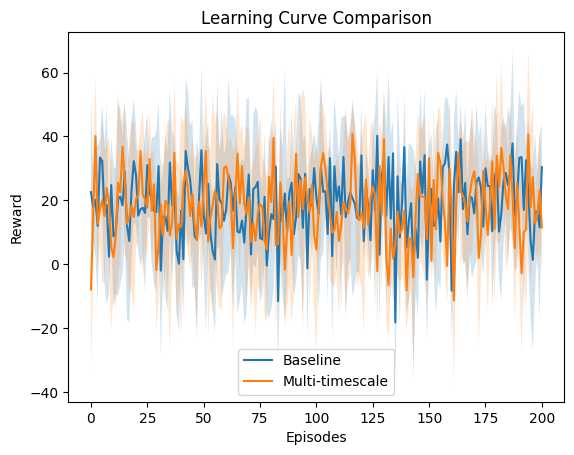

In [12]:
plt.figure()

plt.plot(baseline_mean, label="Baseline")
plt.fill_between(
    range(len(baseline_mean)),
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2
)

plt.plot(multi_mean, label="Multi-timescale")
plt.fill_between(
    range(len(multi_mean)),
    multi_mean - multi_std,
    multi_mean + multi_std,
    alpha=0.2
)

plt.legend()
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve Comparison")

plt.show()

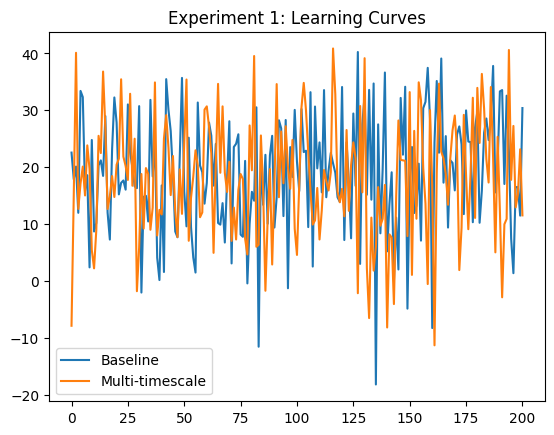

In [13]:
# baseline_mean = baseline_runs.mean(axis=0)
# multi_mean = multi_runs.mean(axis=0)

plt.plot(baseline_mean, label="Baseline")
plt.plot(multi_mean, label="Multi-timescale")

plt.legend()
plt.title("Experiment 1: Learning Curves")
plt.show()
# print(baseline_mean)

## EXPERIMENT 2 — Learner Type Analysis

In [14]:
from env import StudentEnv
from agent import Agent

def evaluate_student(agent, env, steps=100):
    state = env.reset()
    total_reward = 0

    for _ in range(steps):
        action = agent.select_action(state)
        state, reward, _, _ = env.step(action)
        total_reward += reward

    return total_reward

In [36]:
baseline_agent = Agent(state_dim=2, action_dim=4)
multi_agent = Agent(state_dim=4, action_dim=4)

baseline_agent.load("models/v2/300_steps_per_ep/baseline/run_1.pth")
multi_agent.load("models/v2/300_steps_per_ep/multi/run_1.pth")

baseline_agent.epsilon = 0.0
multi_agent.epsilon = 0.0

In [53]:
# Slow but strong learner
baseline_env = StudentEnv(multi_timescale=False)
baseline_env.true_ability = 0.8
baseline_env.true_speed = 0.3

baseline_score = evaluate_student(baseline_agent, baseline_env)

multitime_env = StudentEnv(multi_timescale=True)
multitime_env.true_ability = 0.8
multitime_env.true_speed = 0.3

multitime_score = evaluate_student(multi_agent, multitime_env)

print("Baseline:", baseline_score)
print("Multi:", multitime_score)

Baseline: 6.9139859520136735
Multi: 6.999999999999994


## EXPERIMENT 3 — Stability / Variance

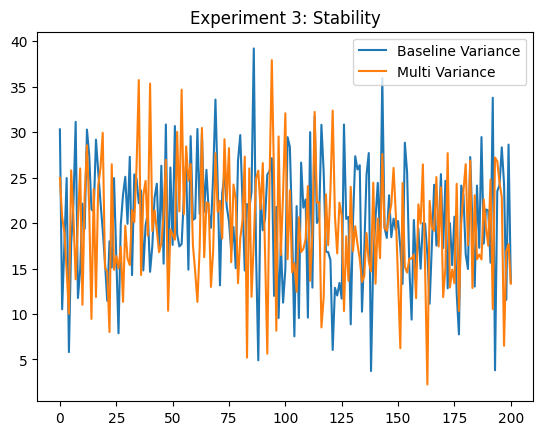

In [26]:
baseline_std = baseline_runs.std(axis=0)
multi_std = multi_runs.std(axis=0)

plt.plot(baseline_std, label="Baseline Variance")
plt.plot(multi_std, label="Multi Variance")

plt.legend()
plt.title("Experiment 3: Stability")
plt.show()